<a href="https://colab.research.google.com/github/SauravSG/Deep-Learning/blob/main/Hands_on_FashionMNIST_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementing the learnings from the notebook, CIFAR10**
Here: https://colab.research.google.com/drive/13Rb0y9ZCkkGDrPPuIapKnZCkurpK1iEb?authuser=1#scrollTo=X1Y-hfqOnuC_

- Reserved the consistency of the complete pipeline.

- **Additionally**, Added the concept of:

  - In Transforms, for better augmentations of the input image:
    - **RandomCrop**
    - **Normalization (Normalize**)
  
  - **W&B**, for better logging of metrics as well as a better visualiztion of model's overall performance.
    - **wandb.init**
    - **wandb.watch**
    - **wandb.log**

  - **BatchNorm2d** , a part of Normalization technique.

  - **Dropout**, a part of Regularization technique.

  - **LRScheduler**, for better optimization of model training.

  - **Early Stopping**, again, for better training.

  - **Checkpoint**, to save the hyperparamaters when the model was at optimal.

- All of the above are covered in detail in the sections of this notebook.
  


## 1. Setup

This will include importing necessary libraries and fetching the dataset

In [1]:
# import the libraries
import torch
from torch import nn

torch.__version__

'2.10.0+cu128'

In [2]:
# import the dataset

from torchvision.datasets import FashionMNIST

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

'cuda'

## 2. Performing the **Data Augmentation** for better model training

- The images in **FashionMNIST** are of size 28x28. We don't need to resize it to say 64x64 as it would just stretch the image resulting in increasing the size, more pixels, same information.

- We'll do random horizontal flip with probability of 50%.

- We'll do random crop of the size 28x28 along with padding=4. The reason behind doing this is to make model trained enough that if it sees even a part of the image, it should be able to predict correctly. Our image is already 28x28, why cropping 28 meaning entire image? That's why we added padding 4 where it adds more pixels on the outline, so the image becomes 32x32.

- We'll convert those incoming images to to tensors bringing all the values from [0, 1]

- We'll normalize the images after converting to tensors. Since ToTensor()
already maps pixels to [0, 1], applying mean=0.5 and std=0.5 maps them
exactly to [-1, 1]. This is input preprocessing — different from BatchNorm
inside the network, which normalizes to mean ~0 and std ~1 but has no fixed
output range.

- Since the images are grayscale images, we would need only two 0.5 as parameters. 0.5 is assumption for the model that the colour channels (grayscale, rgb) have mean and std deviation of 0.5.

In [4]:
# preparing the transform to overall transform the images
from torchvision import transforms

data_transforms= transforms.Compose([
    # transforms.Resize(size=(28,28)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(28, padding = 4),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [5]:
data_transforms

Compose(
    RandomHorizontalFlip(p=0.5)
    RandomCrop(size=(28, 28), padding=4)
    ToTensor()
    Normalize(mean=[0.5], std=[0.5])
)

## 3. Splitting into training and testing datasets

In [6]:
from torchvision.datasets import FashionMNIST
train_data = FashionMNIST(
    root = 'data',
    train = True,
    transform = data_transforms,
    download = True
)

test_data = FashionMNIST(
    root = 'data',
    train = False,
    transform = data_transforms,
    download = True
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.84MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.0MB/s]


In [7]:
train_data.classes, train_data.targets

(['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 tensor([9, 0, 0,  ..., 3, 0, 5]))

TypeError: Invalid shape (1, 28, 28) for image data

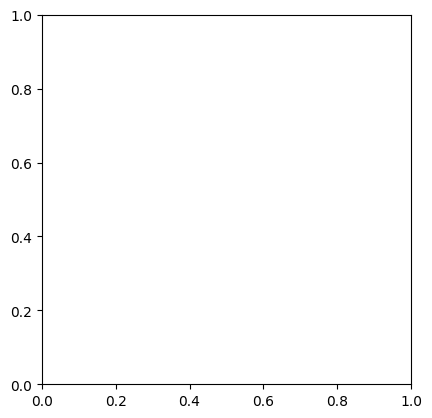

In [8]:
# This would throw error as the order of CC, H, W does not aligns with matplotlib's configuration.
import matplotlib.pyplot as plt
image, label = train_data[0]

new_image = image
plt.imshow(new_image, cmap='gray')
plt.show()

In [9]:
image.shape

torch.Size([1, 28, 28])

torch.Size([1, 28, 28]) 9


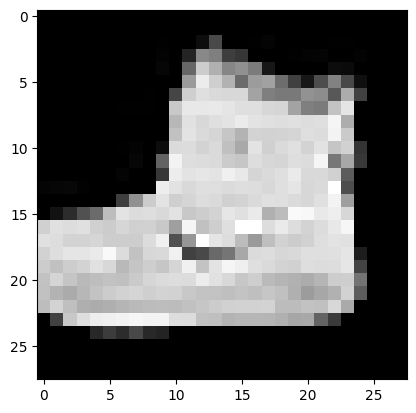

In [10]:
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.cuda.manual_seed(42)

img, lbl = train_data[0]
print(img.shape, lbl)
# permute reorders [C, H, W] -> [H, W, C] i.e [1, 28, 28] -> [28, 28, 1]
# Matplotlib expects [H, W, C] not [C, H, W]
plt.imshow(img.permute(1, 2, 0), cmap='gray')
plt.show()

## 4. Prepare the DataLoaders to the datasets into batches for training and testing

In [11]:
# DataLoader setup
from torch.utils.data import DataLoader
import os

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader = DataLoader(train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True,
                              num_workers = NUM_WORKERS)

test_dataloader = DataLoader(test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False,
                             num_workers = NUM_WORKERS)

## 5. Setting up **W&B** to log our model's hyperparameters and performances

- Install wandb
- login into wandb

In [12]:
# Install W&B
!pip install wandb

In [13]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: saurav071299 (saurav071299-self) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 6. Create the TinyVGG model

### 6.1 Introducing the concept of BatchNorm2d, Dropout

- Role of **nn.BatchNorm2d()** ->

  - It is a part of the **Normalization** technique. BatchNorm2d rescales the incoming output
    of Conv2d to have a mean of ~0 and std of ~1. It doesn't bound outputs to any fixed range
    like -1 to 1, values like -2.5 or 3.8 are still possible. That's where ReLU() comes in,
    zeroing the negatives and keeping the positives.

  - Even if Conv2d outputs contain wildly different values like 0.002 and 500, BatchNorm2d
    brings them to a consistent scale — centered and comparable — before passing them forward.

- Role of **nn.Dropout()** ->

  - The whole point of Dropout is to randomly zero some activations during training so neurons
    don't become too dependent on each other. During eval, all activations pass through untouched.

  - You are responsible for switching modes manually. model.train() enables Dropout, model.eval()
    disables it, PyTorch doesn't auto-switch. nn.Dropout(p=0.2) means 20% of activations are
    randomly zeroed each pass during training. The neurons and their weights still exist, only
    their output is silenced for that pass.

In [14]:
# Reinstalling the libraries for completeness
import torch
from torch import nn

class TinyVGGModel(nn.Module):

  # creating model's constructor as it helps in constructing a model'ss instance
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):

    # Using super(), call the parent class constructor to initialize nn.Module's internals
    super().__init__()

    self.conv_layer_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.MaxPool2d(kernel_size = 2)
    )

    self.conv_layer_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.MaxPool2d(kernel_size = 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*7*7,
                  out_features = output_shape)
    )

  def forward(self,x):
    return self.classifier(self.conv_layer_2(self.conv_layer_1(x)))

In [15]:
model_0 = TinyVGGModel(input_shape = 1,
                       hidden_units = 64,
                       output_shape = len(train_data.classes)).to(device)

model_0

TinyVGGModel(
  (conv_layer_1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
  

## 7. Figuring out the nn.Linear's **in_features=** value

* How to know what value to add in the `in_features = hidden_units * ? * ?`

* It is quite simple:
  
  - Rule 1 - Conv2d
    
    - if padding = 0 -> size shrinks by (kernel_size - 1)
      - output_size = input_size - (kernel_size - 1)
      - eg: `28 - (3-1) = 28 - 2 = 26`
    - if padding = 1 -> size remains unchanged (in case of odd kernel size). padding = 1 adds pixels border on all 4 sides. 28 becomes 30 x30 temporarily.
      - `30 - (3-1) = 30 - 2 = 28` -> unchanged size.

  - Rule 2 - MaxPool2d
    - Always divide by kernel_size
      - eg: MaxPool2d(2) -> 28/2 = 14.
            MaxPool2d(3) -> 28/3 = 7.

  - Rule 3 - ReLU() -> Never changes size. Same goes for Dropout, BatchNorm

  - Rule 4 - Linear input size
    - after all conv blocks are done:
      - in_features = final_channels x final_height x final_weight

* So, in our case, this would go like:
  - start: 1 x 28 x 28
    
    Conv(k=3, p=1): 10 x 28 x 28 -> no size change

    Conv(k=3, p=1): 10 x 28 x 28 -> no change

    MaxPool(2): 10 x 14 x 14 -> halved

    Conv(k=3, p=1): 10 x 14 x 14 -> no size change

    Conv(k=3, p=1): 10 x 14 x 14 -> no change

    MaxPool(2): 10 x 7 x 7 -> halved

    Linear in_features = 10 x 7 x 7 -> 490




In [16]:
!pip install torchinfo

In [17]:
import torchinfo
from torchinfo import summary

summary(model_0, input_size = [32, 1, 28, 28])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGGModel                             [32, 10]                  --
├─Sequential: 1-1                        [32, 64, 14, 14]          --
│    └─Conv2d: 2-1                       [32, 64, 28, 28]          640
│    └─BatchNorm2d: 2-2                  [32, 64, 28, 28]          128
│    └─ReLU: 2-3                         [32, 64, 28, 28]          --
│    └─Dropout: 2-4                      [32, 64, 28, 28]          --
│    └─Conv2d: 2-5                       [32, 64, 28, 28]          36,928
│    └─BatchNorm2d: 2-6                  [32, 64, 28, 28]          128
│    └─ReLU: 2-7                         [32, 64, 28, 28]          --
│    └─Dropout: 2-8                      [32, 64, 28, 28]          --
│    └─MaxPool2d: 2-9                    [32, 64, 14, 14]          --
├─Sequential: 1-2                        [32, 64, 7, 7]            --
│    └─Conv2d: 2-10                      [32, 64, 14, 14]          36,928
│   

## 8. Setup wandb init and wandb watch to initialise the run and watch how the model performs

- `wandb.init()` initiates a new run everytime it is executed. It is a unit of execution. Every Run has an ID based on which we can watch the model perform.

- `wandb.watch()` basically watch and logs all the hyperparameters and even create the histograms of gradients and parameters.

In [18]:
import wandb
run = wandb.init(project='FashionMNIST Hands-On', config = {'lr': 0.001,
                                                                     'epochs': 32,
                                                            'batch_size': 32})
wandb.watch(model_0, log = 'all')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: saurav071299 (saurav071299-self) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 9. Setup Loss, Optimizer and Scheduler

- We will be using CrossEntropyLoss() for this model as a loss function.

- For optimizer, we'll be using AdamW

Adam is an optimizing algorithm or a technique to optimize the training where takes the gradients into consideration (instead of weights) and does two things:
 - m -> average of recent gradients. Decides which direction to move. if -ve, increase the value and if +ve, decrease the value. The goal is to have small loss value, closer to 0.

 - v ->  average of squared gradients. How large/noisy the gradients have been -> controls how much to trust the direction

Step becomes:
 `step = lr / sqrt(v)   ×   m`

Noisy weight → v is big → step shrinks. Calm weight → v is small → step grows.

**What Adam doesn't do**

- Adam only ever sees gradients. Never the weight value itself.
So if a weight slowly grows to 90.0 over many updates — Adam doesn't care. Nothing in its math says "hey this is getting big, slow down." It just keeps updating based on gradients.
That's the gap.

**AdamW**

AdamW is basically Adam + Weight Decay.

Adam does its gradient calculation. Once done, the weight decay part cuts some part by a small fixed values, so the next time gradient is calculated in next epoch, the weight is already smaller, weight decay cuts the weight down after each update, so large weights slowly get pulled back toward zero over time.

---
- For scheduler, let's use ReduceLROnPlateu

LRScheduler is a technique that automatically identifies how big or small the steps need to be taken to reach the destined weight.

Initial training -> big steps -> explore broadly, move fast
Close to finsih training -> small steps -> settle carefully into a good minimum

ReduceLROnPlatue is one of the LR scheduler where it wait (patience) for certain number of epochs to see if there's any improvement/reduce in the loss. If yes, good, keep going. If not, reduce the lr with defined factor parameter. So,
- factor - is modified value of lr after patience is lost
- threshold — it's not between actual and loss values. It's between the current best loss and the new loss. If the new loss didn't beat the best by at least threshold, it doesn't count as improvement. That's when patience starts ticking.

In [19]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params = model_0.parameters(), lr = 0.001, weight_decay = 0.0001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor = 0.1,
                                                      patience = 3,
                                                      threshold = 0.0001)

In [20]:
loss_fn, optimizer

(CrossEntropyLoss(),
 AdamW (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: True
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0.0001
 ))

## 10. Building Training and Validation loop

In [21]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               device = device):

  ### Training
  model.train()

  # accumulate the train's and test's loss and accuracy
  train_loss, train_acc = 0, 0

  # loop through batches
  for batch, (X_train, y_train) in enumerate(dataloader):

    X_train, y_train = X_train.to(device), y_train.to(device)

    # zero the previous gradients
    optimizer.zero_grad()

    # forward pass
    y_train_logits = model(X_train)

    # calculate the loss
    y_train_loss = loss_fn(y_train_logits, y_train)
    train_loss += y_train_loss.item() #-> converting the loss value in plain python otherwise all the tensors would get added with train_loss

    # bringing the logits into 0 to 1 inclusive values
    y_train_prob = torch.softmax(y_train_logits, dim = 1)

    # taking the max predicted values and converting into plain python
    y_train_label = torch.argmax(y_train_prob, dim = 1)

    # calculate the accuracy
    train_accuracy = ((y_train_label == y_train).sum().item()/len(y_train_logits))

    train_acc += train_accuracy

    # loss backward
    y_train_loss.backward()

    # update weights using computed gradients
    optimizer.step()

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc

In [22]:
def test_step(model: torch.nn.Module,
             dataloader: torch.utils.data.DataLoader,
             loss_fn = loss_fn,
             device = device):

  ### eval mode
  model.eval()

  # accumulate test loss and accuracy
  test_loss, test_acc = 0, 0

  with torch.inference_mode():

    for batch, (X_test, y_test) in enumerate(dataloader):

      X_test, y_test = X_test.to(device), y_test.to(device)

      # forward pass
      y_test_logits = model(X_test)

      # calculate loss
      y_test_loss = loss_fn(y_test_logits, y_test)
      test_loss += y_test_loss.item() #-> converting the loss value in plain python otherwise all the tensors would get added with test_loss

      y_test_prob = torch.softmax(y_test_logits, dim = 1)

      # taking the max predicted values and converting into plain python
      y_test_label = torch.argmax(y_test_prob, dim = 1)

      # calculate accuracy
      y_test_accuracy = ((y_test_label == y_test).sum().item()/len(y_test_logits))

      test_acc += y_test_accuracy

  test_loss /= len(dataloader)
  test_acc /= len(dataloader)

  return test_loss, test_acc

## 11. Early Stopping

In order to protect the model from overfitting and wasted compute time, we introduce
**early stopping**.

The purpose of **early stopping** is to determine if there is any improvement in the training or not. If there's any, keep going. If no, stop the training after so number of ideal epochs. That is the base line significance of **early stopping**

Note: early stopping specifically guards against overfitting. Stopping
too early actually causes underfitting, which is why the patience and delta values need to be tuned carefully.

In [23]:
def early_stopping(patience: int,
                   best_test_loss: float,
                   test_loss: float,
                   delta: float,
                   no_improvement_count: int):

  if best_test_loss is None or test_loss < best_test_loss - delta:

    best_test_loss = test_loss
    no_improvement_count = 0
  else:
    no_improvement_count += 1

    if no_improvement_count >= patience:
      print(f'Early stopping after {no_improvement_count} counts of no improvement in the test_loss')
      return True, best_test_loss, no_improvement_count

  return False, best_test_loss, no_improvement_count

## 12. Training and evaluating the model

In [24]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

def train(model: torch.nn.Module,
          trainDataloader: torch.utils.data.DataLoader,
          testDataloader: torch.utils.data.DataLoader,
          run: wandb, # -> to log the metrics like loss and acc for the specific run id for the model
          loss_fn = loss_fn,
          optimizer = optimizer,
          device = device):

  best_early_stop_loss = float('inf')
  best_checkpoint_loss = float('inf')
  no_improvement_count = 0
  patience = 7
  delta = 0.005
  epochs = run.config.epochs # -> the one defined in the wandb.init's config part

  results = {
      'epoch': [],
      'train_loss': [],
      'train_acc': [],
      'test_loss': [],
      'test_acc': []}



  for epoch in range(epochs):

    train_loss, train_acc = train_step(model = model,
                                       dataloader = trainDataloader,
                                       loss_fn = loss_fn,
                                       optimizer = optimizer,
                                       device = device)

    test_loss, test_acc = test_step(model = model,
                                    dataloader = testDataloader,
                                    loss_fn = loss_fn,
                                    device = device)


    # log the metrics like loss and accuracy
    wandb.log({
        'epoch':epoch,
        'train_loss':train_loss,
        'train_acc':train_acc,
        'test_loss':test_loss,
        'test_acc':test_acc,
        'lr':optimizer.param_groups[0]['lr'] # -> pick the current lr from the optimizer's first param groups
    })

    # adding scheduler here to check for every epoch, if any update in lr is required based on the test loss
    scheduler.step(test_loss)

    early_stop, best_early_stop_loss, no_improvement_count = early_stopping(
        patience = patience,
        best_test_loss = best_early_stop_loss,
        test_loss = test_loss,
        delta = delta,
        no_improvement_count = no_improvement_count
    )

    # Adding a checkpoint to fetch the best states of hyperparameter where the model was at optimal
    if test_loss < best_checkpoint_loss:
      best_checkpoint_loss = test_loss

      torch.save({
          'epoch':epoch,
          'model_state_dict':model.state_dict(),
          'optimizer_state_dict':optimizer.state_dict(),
          'best test loss':best_checkpoint_loss
      },
                 'checkpoint_saved.pth')

    results['epoch'].append(epoch)
    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)

    # if early stop returns true
    if early_stop:
      break

  return results

In [25]:
model_0_results = train(model = model_0,
                        trainDataloader = train_dataloader,
                        testDataloader = test_dataloader,
                        run = run)

model_0_results

{'epoch': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 'train_loss': [0.6632633443673451,
  0.44721988501548765,
  0.3870814962983131,
  0.35523698412775995,
  0.3288606789032618,
  0.31125218325455983,
  0.2994015381495158,
  0.2877596738576889,
  0.279050254402558,
  0.27273193356196085,
  0.2651822231491407,
  0.25884637693663437,
  0.2562996024926503,
  0.25242411919633545,
  0.24904675485491753,
  0.22247247539361317,
  0.21480616505742073,
  0.21064503579537075,
  0.21154825112819672,
  0.20667146306037903,
  0.2065569280366103,
  0.20718879889448483,
  0.2050935722966989,
  0.20294989102482797,
  0.20452687422583501,
  0.20258358154197534,
  0.19838352751235167,
  0.2000261691570282,
  0.1988318258782228,
  0.19809273471559088,
  0.19806700758238632,
  0.1942421641389529],
 'train_acc': [0.7597166666666667,
  0.8365833333333333,
  0.8607833333

## 13. Check model's performance on a test sample

- For testing, we would give a fixed_input to the trained model to see how it performs.

- We pick a single image from the dataloader and pass it in to the model to evaluate/test if the model can predict the passed image correctly

In [26]:
def test_sample(model:torch.nn.Module,
                dataloader:torch.utils.data.DataLoader,
                fixed_input = None):

  if fixed_input is None:
    image_batch, label = next(iter(dataloader))
    single_image, single_label = image_batch[0], label[0]
    print(f'Single image shape: {single_image.shape} \n Single label: {single_label}')
    fixed_input = single_image.unsqueeze(0)

  model.eval()
  with torch.inference_mode():

    logits = model(fixed_input.to(device))
    pred_prob = torch.softmax(logits, dim = 1)
    pred_label = torch.argmax(pred_prob, dim = 1)

  return pred_prob, pred_label, fixed_input

In [27]:
# Load the checkpoints -> Hyperparameters where model was performing well
load_checkpoint = torch.load('/content/checkpoint_saved.pth', weights_only = True)

load_checkpoint

{'epoch': 27,
 'model_state_dict': OrderedDict([('conv_layer_1.0.weight',
               tensor([[[[ 2.7611e-01, -1.7713e-01, -1.1960e-01],
                         [-3.2413e-01,  2.0061e-01,  1.6196e-01],
                         [-4.2306e-01,  3.9522e-01,  1.0326e-02]]],
               
               
                       [[[ 1.8028e-01, -1.3558e-01, -7.1253e-02],
                         [-2.3658e-01,  4.0996e-01, -1.0368e-01],
                         [-1.8140e-01,  3.2697e-01, -2.0278e-01]]],
               
               
                       [[[-5.5076e-02, -1.3915e-01,  2.4809e-01],
                         [-1.0669e+00, -4.7431e-01, -1.3486e-02],
                         [-7.6712e-02,  2.1025e-01, -2.4785e-02]]],
               
               
                       [[[ 3.5768e-01, -4.2416e-01,  2.6650e-01],
                         [ 5.5562e-03, -2.9997e-01,  1.3713e-01],
                         [-5.5708e-02,  2.7285e-01, -1.5940e-01]]],
               
              

In [28]:
# Creating a new instance of the model
model_1 = TinyVGGModel(input_shape = 1,
                       hidden_units = 64,
                       output_shape = len(train_data.classes)).to(device)

In [29]:
# resetting model_0 to its best checkpoint weights instead of the final epoch weights
# model_0 after training holds the last epoch's weights, not necessarily the best ones
model_0.load_state_dict(load_checkpoint['model_state_dict'])

<All keys matched successfully>

In [30]:
# loading the best weights and biases from model_0's state_dict from the checkpoint
model_1.load_state_dict(load_checkpoint['model_state_dict'])

<All keys matched successfully>

In [31]:
original_pred_prob, original_pred_label, fixed_input = test_sample(model = model_0,
                                             dataloader = test_dataloader)

load_pred_prob, load_pred_label, _ = test_sample(model = model_1,
                                dataloader = test_dataloader,
                                fixed_input = fixed_input)

# check both predict the same label, not probabilities
print(f'model_0 predicted: {train_data.classes[original_pred_label]}')
print(f'model_1 predicted: {train_data.classes[load_pred_label]}')

Single image shape: torch.Size([1, 28, 28]) 
 Single label: 9
model_0 predicted: Ankle boot
model_1 predicted: Ankle boot


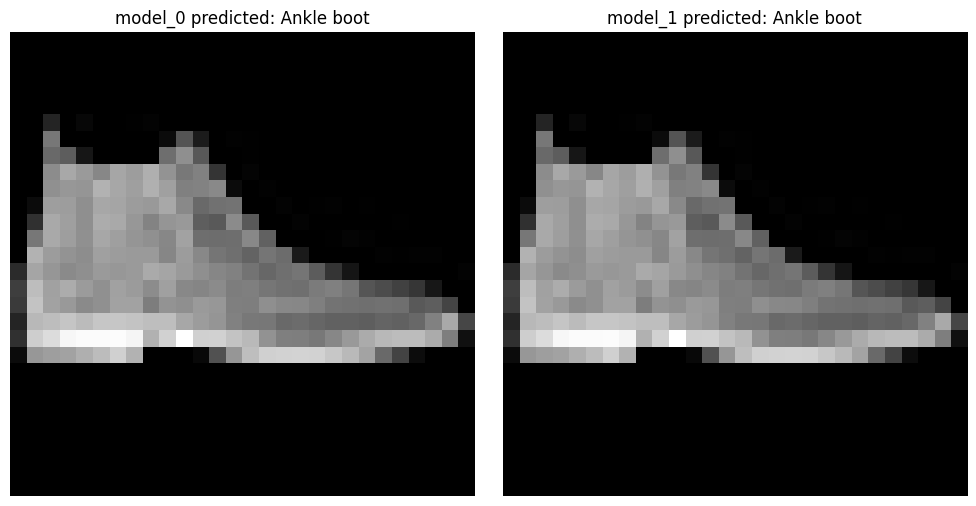

In [49]:
img_to_show = fixed_input.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_to_show, cmap='gray')
axes[0].set_title(f'model_0 predicted: {class_names[original_pred_label]}')
axes[0].axis('off')

axes[1].imshow(img_to_show, cmap='gray')
axes[1].set_title(f'model_1 predicted: {class_names[load_pred_label]}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [43]:
original_pred_prob.shape

torch.Size([1, 10])